# **Supervised Fraud Classification**

## **Project Overview**
This project focuses on classifying financial transactions for potential frauds using **XGBoost Model**

### **Objective**
- Classify suspicious transactions that deviate significantly from normal behavior.

---

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import plotly.io as pio
import shap

# Comment the following line to change the default renderer
pio.renderers.default = "png"

## 1. Data Exploration

First, we load the dataset and explore its structure. This helps us understand the features 
and check for missing values.

In [3]:
data = pd.read_csv("data/supervised_transaction_anomalies_dataset.csv")
data.head()

,Transaction_ID,Transaction_Amount,Transaction_Volume,Average_Transaction_Amount,Frequency_of_Transactions,Time_Since_Last_Transaction,Day_of_Week,Time_of_Day,Age,Gender,Income,Account_Type,is_anomaly
0,TX0,1024.835708,3,997.234714,12,29,Friday,06:00,36,Male,1436074,Savings,False
1,TX1,1013.952065,4,1020.210306,7,22,Friday,01:00,41,Female,627069,Savings,False
2,TX2,970.956093,1,989.496604,5,12,Tuesday,21:00,61,Male,786232,Savings,False
3,TX3,1040.822254,2,969.522480,16,28,Sunday,14:00,61,Male,619030,Savings,False
4,TX4,998.777241,1,1007.111026,7,7,Friday,08:00,56,Female,649457,Savings,False


In [4]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Transaction_ID               1000 non-null   object 
 1   Transaction_Amount           1000 non-null   float64
 2   Transaction_Volume           1000 non-null   int64  
 3   Average_Transaction_Amount   1000 non-null   float64
 4   Frequency_of_Transactions    1000 non-null   int64  
 5   Time_Since_Last_Transaction  1000 non-null   int64  
 6   Day_of_Week                  1000 non-null   object 
 7   Time_of_Day                  1000 non-null   object 
 8   Age                          1000 non-null   int64  
 9   Gender                       1000 non-null   object 
 10  Income                       1000 non-null   int64  
 11  Account_Type                 1000 non-null   object 
 12  is_anomaly                   1000 non-null   bool   
dtypes: bool(1), float64

In [5]:
print(data.describe())

       Transaction_Amount  Transaction_Volume  Average_Transaction_Amount  \
count         1000.000000         1000.000000                 1000.000000   
mean          1038.122511            2.498000                 1000.682506   
std            283.580055            1.115006                   20.632334   
min            849.024392            1.000000                  939.081423   
25%            966.028796            1.000000                  986.800556   
50%           1002.118678            3.000000                 1000.501902   
75%           1033.143657            3.000000                 1015.155595   
max           3227.459108            4.000000                 1073.154036   

       Frequency_of_Transactions  Time_Since_Last_Transaction          Age  \
count                1000.000000                  1000.000000  1000.000000   
mean                   12.078000                    15.341000    40.641000   
std                     4.245225                     8.361258    13.8199

In [6]:
data['hour'] = pd.to_datetime(data['Time_of_Day'], format='%H:%M').dt.hour

## 2. Data Visualization

We analyze the distribution of transaction amounts and their relationships with other features.

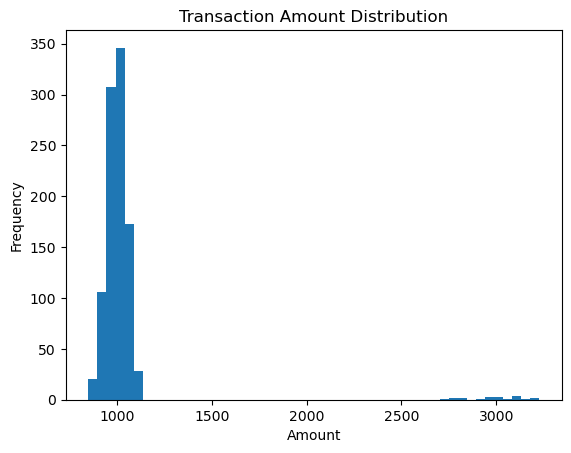

In [7]:
plt.hist(data['Transaction_Amount'], bins=50)
plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

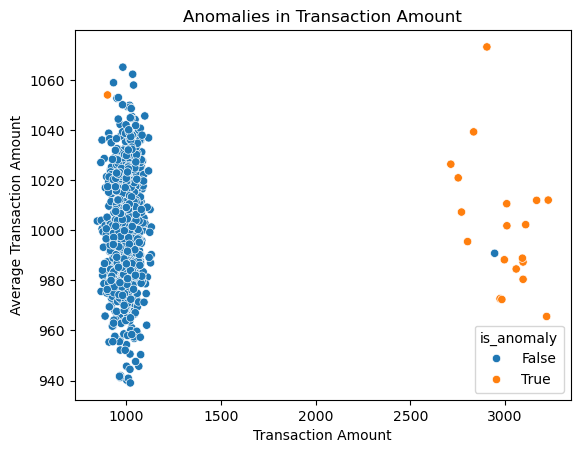

In [8]:
sns.scatterplot(x=data['Transaction_Amount'], y = data['Average_Transaction_Amount'], hue=data['is_anomaly'])
plt.title('Anomalies in Transaction Amount')
plt.xlabel('Transaction Amount')
plt.ylabel('Average Transaction Amount')
plt.show()

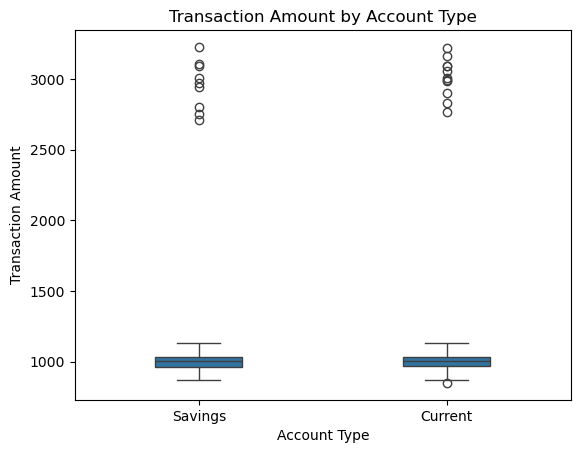

In [9]:
sns.boxplot(y=data['Transaction_Amount'], x=data['Account_Type'], width=0.5, gap=0.3)
plt.xlabel('Account Type')
plt.ylabel('Transaction Amount')
plt.title('Transaction Amount by Account Type')
plt.show()

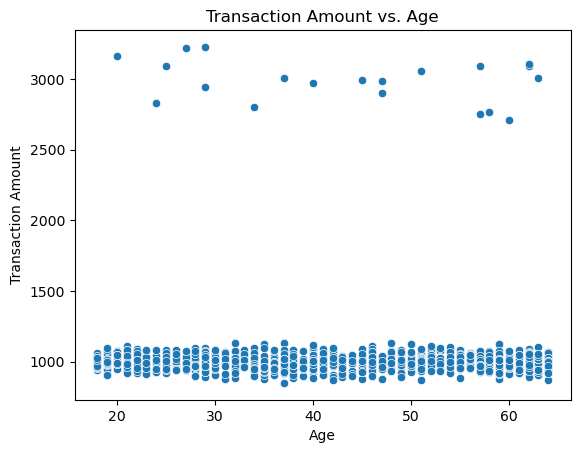

In [10]:
# Average Transaction Amount vs. Age
sns.scatterplot(data=data, x='Age', y='Transaction_Amount')
plt.title('Transaction Amount vs. Age')
plt.xlabel('Age')
plt.ylabel('Transaction Amount')
plt.show()

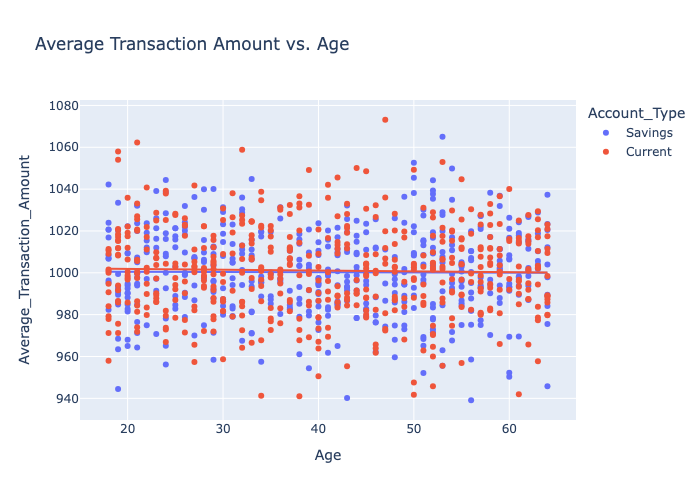

In [11]:
# Average Transaction Amount vs. Age
fig_scatter_avg_amount_age = px.scatter(data, x='Age',
                                        y='Average_Transaction_Amount',
                                        color='Account_Type',
                                        title='Average Transaction Amount vs. Age',
                                        trendline='ols')
fig_scatter_avg_amount_age.show()

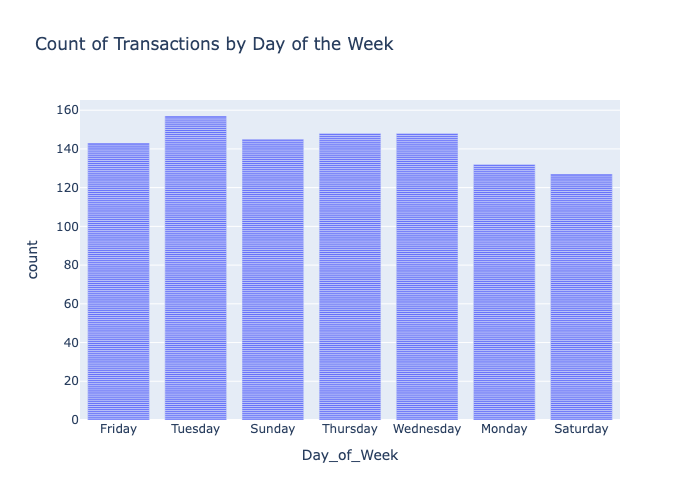

In [12]:
# Count of Transactions by Day of the Week
fig_day_of_week = px.bar(data, x='Day_of_Week',
                         title='Count of Transactions by Day of the Week')
fig_day_of_week.show()

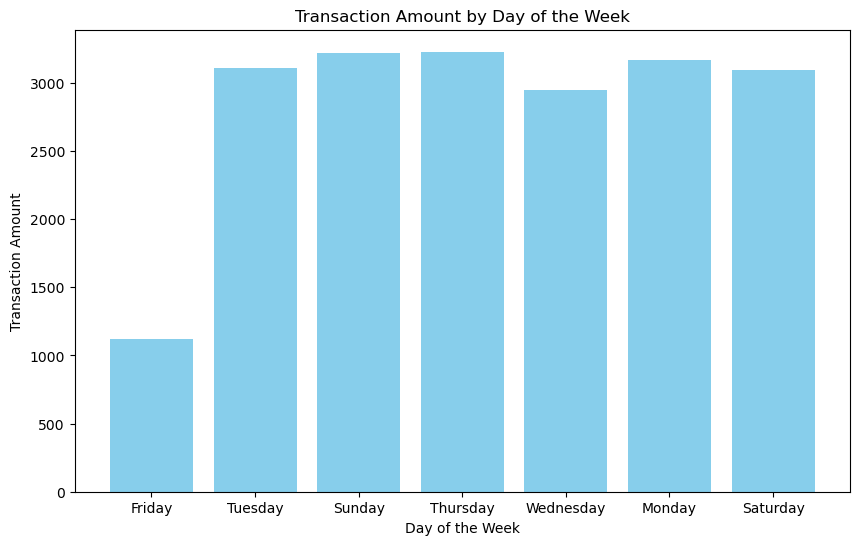

In [13]:
plt.figure(figsize=(10, 6))
plt.bar(data['Day_of_Week'], height=data['Transaction_Amount'], color='skyblue')
plt.title('Transaction Amount by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Transaction Amount')
plt.show()

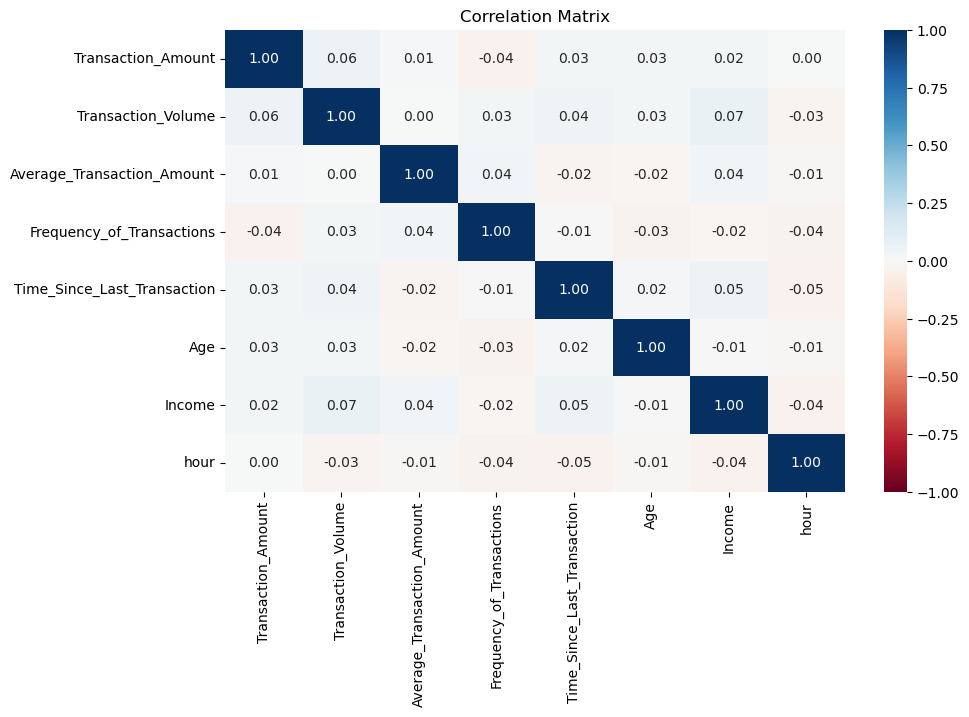

In [14]:
correlation_matrix = data.select_dtypes(include='number').corr()

# PLot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

## 3. Fraud Classification

In [15]:
features = [
    'Transaction_Amount',
    'Average_Transaction_Amount',
    'Income',
    'hour',
    'Time_Since_Last_Transaction',
    'Transaction_Volume',
    'Frequency_of_Transactions',
    # 'Account_Type'
]

X = data[features]
y = data['is_anomaly']

In [16]:
# Calculate the number of anomalies
num_anomalies = data['is_anomaly'].sum()

# Calculate the total number of instances in the dataset
total_instances = data.shape[0]

# Calculate the ratio of anomalies
anomaly_ratio = num_anomalies / total_instances

print(f'Number of anomalies: {num_anomalies}')
print(f'% of anomalies in the data: {anomaly_ratio:.2%}')

Number of anomalies: 20
% of anomalies in the data: 2.00%


## 4. Model Training 

We use **XGBoost** to classify anomalous transactions. Before training, we balance the dataset using **SMOTE**.

In [30]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

smote = SMOTE(sampling_strategy=0.2, random_state=42)  # Increase anomalies to 10%
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Train the Isolation Forest model
model = xgb.XGBClassifier(scale_pos_weight=0.02, eval_metric='logloss')
model.fit(X_train_balanced, y_train_balanced)
# model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

## 5. Model Evaluation

We evaluate the **precision, recall, and accuracy** of our model using a confusion matrix and classification report.

In [31]:
# Predict anomalies on the test set
y_pred = model.predict(X_test)

# Evaluate the model's performance
report = classification_report(y_test, y_pred, target_names=['Normal', 'Anomaly'])
print(report)

# Print confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

              precision    recall  f1-score   support

      Normal       0.98      0.99      0.99       196
     Anomaly       0.00      0.00      0.00         4

    accuracy                           0.97       200
   macro avg       0.49      0.50      0.49       200
weighted avg       0.96      0.97      0.97       200

[[195   1]
 [  4   0]]


In [19]:
probab = model.predict_proba(X_test)[:, 1]

y_pred = (probab > 0.2).astype(int)

In [20]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, thresholds = precision_recall_curve(y_test, probab)
pr_auc = auc(recall, precision)
print(f'Precision-Recall AUC: {pr_auc:.4f}')

Precision-Recall AUC: 0.5792
